In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/sample_submission.csv
/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test_labels.csv
/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv
/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test.csv


In [2]:
import os
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"

import seaborn as sns

from sklearn.metrics import (
    precision_recall_fscore_support,
    f1_score,
    multilabel_confusion_matrix,
    roc_auc_score
 )
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
from peft import LoraConfig, get_peft_model

CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if CUDA_AVAILABLE else "cpu")
print(f"Using device: {DEVICE}")
if CUDA_AVAILABLE:
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [3]:
TARGET = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

train_path = '/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv'
if not os.path.exists(train_path):
    train_path = 'data/train.csv'

df = pd.read_csv(train_path)
print(f"Loaded train data from: {train_path}")

Loaded train data from: /kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv


In [4]:
USE_RAG = True
RAG_TOP_K = 3
RAG_MAX_CHARS = 180
RAG_MAX_FEATURES = 50000

def clean_text(text):
    return str(text).replace("\n", " ").strip()

def build_rag_retriever(reference_texts, max_features=RAG_MAX_FEATURES):
    vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2),
        min_df=3,
        max_features=max_features
    )
    reference_matrix = vectorizer.fit_transform(reference_texts.fillna("").map(clean_text).tolist())
    nn_index = NearestNeighbors(metric="cosine", algorithm="brute")
    nn_index.fit(reference_matrix)
    return vectorizer, nn_index

def format_retrieved_context(retrieved_rows):
    # Avoid label leakage: only include retrieved text.
    snippets = []
    for _, row in retrieved_rows.iterrows():
        snippet = clean_text(row["comment_text"])[:RAG_MAX_CHARS]
        if snippet:
            snippets.append(snippet)
    return " ".join(snippets)

def build_augmented_texts(query_texts, reference_df, vectorizer, nn_index, top_k=RAG_TOP_K, drop_self=False):
    query_clean = query_texts.fillna("").map(clean_text)
    if len(reference_df) == 0:
        return [""] * len(query_clean)

    query_matrix = vectorizer.transform(query_clean.tolist())
    neighbors_to_request = min(len(reference_df), top_k + (1 if drop_self else 0))
    _, neighbor_indices = nn_index.kneighbors(query_matrix, n_neighbors=neighbors_to_request)

    augmented = []
    for row_pos, _ in enumerate(query_clean):
        idx_list = neighbor_indices[row_pos].tolist()
        if drop_self:
            idx_list = [idx for idx in idx_list if idx != row_pos]
        idx_list = idx_list[:top_k]
        context = format_retrieved_context(reference_df.iloc[idx_list])
        augmented.append(context)
    return augmented

In [5]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6
    )

cols = ['comment_text'] + TARGET
train_pd, val_pd  = train_test_split(df[cols], test_size=0.2, random_state=42)
train_pd = train_pd.reset_index(drop=True)
val_pd = val_pd.reset_index(drop=True)

if USE_RAG:
    rag_vectorizer, rag_nn = build_rag_retriever(train_pd['comment_text'])
    train_pd['context_text'] = build_augmented_texts(
        query_texts=train_pd['comment_text'],
        reference_df=train_pd,
        vectorizer=rag_vectorizer,
        nn_index=rag_nn,
        top_k=RAG_TOP_K,
        drop_self=True
    )
    val_pd['context_text'] = build_augmented_texts(
        query_texts=val_pd['comment_text'],
        reference_df=train_pd,
        vectorizer=rag_vectorizer,
        nn_index=rag_nn,
        top_k=RAG_TOP_K,
        drop_self=False
    )
else:
    train_pd['context_text'] = ""
    val_pd['context_text'] = ""

MAX_LENGTH = min(512, tokenizer.model_max_length)

def tokenize_pair(comment_text, context_text):
    comment_text = clean_text(comment_text)
    context_text = clean_text(context_text)
    pair_special = tokenizer.num_special_tokens_to_add(pair=True)
    comment_ids = tokenizer.encode(comment_text, add_special_tokens=False, truncation=False)
    if not context_text or len(comment_ids) >= MAX_LENGTH - pair_special:
        return tokenizer(
            comment_text,
            padding='max_length',
            truncation=True,
            max_length=MAX_LENGTH
        )
    return tokenizer(
        comment_text,
        context_text,
        padding='max_length',
        truncation='only_second',
        max_length=MAX_LENGTH
    )

def preprocess(examples):
    tokens = tokenize_pair(examples['comment_text'], examples['context_text'])

    labels = [float(examples[label]) for label in TARGET]
    tokens['labels'] = labels
    return tokens

dataset_cols = ['comment_text', 'context_text'] + TARGET

train_df = Dataset.from_pandas(train_pd[dataset_cols])
train_ds = train_df.map(preprocess, batched=False)
train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

val_df = Dataset.from_pandas(val_pd[dataset_cols])
val_ds = val_df.map(preprocess, batched=False)
val_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

print(f"RAG enabled: {USE_RAG}, top_k: {RAG_TOP_K}, device: {DEVICE}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/127656 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (978 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/31915 [00:00<?, ? examples/s]

RAG enabled: True, top_k: 3, device: cuda


In [7]:
config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_lin", "v_lin"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"
 )

lora_model = get_peft_model(distilbert_model, config)
lora_model.config.problem_type = "multi_label_classification"

if not CUDA_AVAILABLE:
    raise RuntimeError("CUDA is not available. Enable GPU runtime to run this notebook on CUDA.")

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

lora_model = lora_model.to(DEVICE)
lora_model.print_trainable_parameters()

use_bf16 = torch.cuda.is_bf16_supported()
print(f"Mixed precision mode: {'bf16' if use_bf16 else 'fp16'}")

training_args = TrainingArguments(
    output_dir="./toxic_lora",
    learning_rate=2e-5,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=500,
    fp16=not use_bf16,
    bf16=use_bf16,
    dataloader_pin_memory=True,
    report_to="none"
 )

def compute_metrics(eval_pred, threshold=0.5):
    logits = eval_pred.predictions if hasattr(eval_pred, "predictions") else eval_pred[0]
    labels = eval_pred.label_ids if hasattr(eval_pred, "label_ids") else eval_pred[1]
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= threshold).astype(int)
    return {
        "f1_micro": f1_score(labels, preds, average="micro"),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
 )


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


trainable params: 742,662 || all params: 67,700,748 || trainable%: 1.0970
Mixed precision mode: bf16


In [8]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
500,0.412464
1000,0.146564
1500,0.144999
2000,0.129289
2500,0.125497
3000,0.116568
3500,0.119224
4000,0.121434
4500,0.115772
5000,0.114485


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


TrainOutput(global_step=11970, training_loss=0.12990478158694263, metrics={'train_runtime': 8024.4989, 'train_samples_per_second': 47.725, 'train_steps_per_second': 1.492, 'total_flos': 5.160811885255066e+16, 'train_loss': 0.12990478158694263, 'epoch': 3.0})

In [9]:
eval_results = trainer.evaluate()
print("\n" + "="*80)
print("Метрики RAG + LoRa BERT модели:")
print("="*80)
for metric_name, metric_value in eval_results.items():
    print(f"{metric_name}: {metric_value}")

    

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



Метрики RAG + LoRa BERT модели:
eval_loss: 0.10820595175027847
eval_f1_micro: 0.6890292028413575
eval_f1_macro: 0.40868145390376603
eval_runtime: 296.7465
eval_samples_per_second: 107.55
eval_steps_per_second: 3.363
epoch: 3.0


In [10]:
eval_results

{'eval_loss': 0.10820595175027847,
 'eval_f1_micro': 0.6890292028413575,
 'eval_f1_macro': 0.40868145390376603,
 'eval_runtime': 296.7465,
 'eval_samples_per_second': 107.55,
 'eval_steps_per_second': 3.363,
 'epoch': 3.0}

In [11]:
lora_model.save_pretrained("/kaggle/working/toxic_lora_adapter")

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_recall_fscore_support,
    f1_score,
    multilabel_confusion_matrix
)

from datasets import Dataset

In [13]:
pred = trainer.predict(val_ds)

logits = pred.predictions
labels = pred.label_ids

probs = 1/(1+np.exp(-logits))
preds = (probs > 0.5).astype(int)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [14]:
precision, recall, f1, support = precision_recall_fscore_support(
    labels,
    preds,
    average=None
)

metrics_df = pd.DataFrame({
    "class": TARGET,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

print(f'Validation ROC-AUC Score (RAG+BERT+LoRa): {roc_auc_score(labels, logits):.4}')
display(metrics_df)

Validation ROC-AUC Score (RAG+BERT+LoRa): 0.9741


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,class,precision,recall,f1,support
0,toxic,0.807663,0.682919,0.740071,3056
1,severe_toxic,0.542373,0.199377,0.291572,321
2,obscene,0.804000,0.703207,0.750233,1715
3,threat,0.000000,0.000000,0.000000,74
4,insult,0.723099,0.624535,0.670213,1614
5,identity_hate,0.000000,0.000000,0.000000,294


In [15]:
print("F1 micro:", f1_score(labels, preds, average="micro"))
print("F1 macro:", f1_score(labels, preds, average="macro"))

F1 micro: 0.6890292028413575
F1 macro: 0.40868145390376603


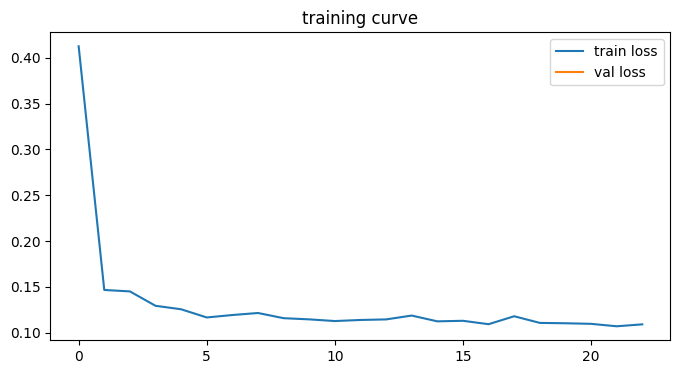

In [16]:
logs = trainer.state.log_history

train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]

plt.figure(figsize=(8,4))

plt.plot(train_loss,label="train loss")
plt.plot(eval_loss,label="val loss")

plt.legend()
plt.title("training curve")

plt.show()

In [17]:
sample_texts = val_pd["comment_text"].head(5).tolist()

pred_table = pd.DataFrame({"text": sample_texts})
for i, label in enumerate(TARGET):
    pred_table[label] = probs[:5, i]

display(pred_table)

,text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,"Geez, are you forgetful! We've already discus...",0.114156,0.000239,0.008706,0.000874,0.027499,0.003010
1,Carioca RFA \n\nThanks for your support on my ...,0.001090,0.000022,0.000482,0.000169,0.000279,0.000096
2,"""\n\n Birthday \n\nNo worries, It's what I do ...",0.005413,0.000072,0.001688,0.000319,0.001215,0.000552
3,Pseudoscience category? \n\nI'm assuming that ...,0.004412,0.000024,0.000859,0.000120,0.000700,0.000292
4,"(and if such phrase exists, it would be provid...",0.006798,0.000021,0.001042,0.000132,0.001290,0.000307


In [18]:
test_path = '/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test.csv'
if not os.path.exists(test_path):
    test_path = 'data/test.csv'

test_df = pd.read_csv(test_path)
print(f"Loaded test data from: {test_path}")

Loaded test data from: /kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test.csv


In [20]:
MAX_LENGTH = min(256, tokenizer.model_max_length)

def _safe_text(value):
    if value is None:
        return ""
    return str(value).replace("\n", " ").strip()

def tokenize_test(example):
    comment_text = _safe_text(example.get("comment_text", ""))
    context_text = _safe_text(example.get("context_text", ""))
    if context_text:
        pair_special = tokenizer.num_special_tokens_to_add(pair=True)
        comment_ids = tokenizer.encode(comment_text, add_special_tokens=False, truncation=False)
        if len(comment_ids) >= MAX_LENGTH - pair_special:
            return tokenizer(
                comment_text,
                padding="max_length",
                truncation=True,
                max_length=MAX_LENGTH
            )
        return tokenizer(
            comment_text,
            context_text,
            padding="max_length",
            truncation="only_second",
            max_length=MAX_LENGTH
        )
    return tokenizer(
        comment_text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

test_dataset = test_dataset.map(tokenize_test)
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])

Map:   0%|          | 0/153164 [00:00<?, ? examples/s]

In [21]:
test_pred = trainer.predict(test_dataset)

logits = test_pred.predictions
probs = 1/(1+np.exp(-logits))

In [22]:
submission = pd.DataFrame(
    probs,
    columns=TARGET
)

submission.insert(0,"id",test_df["id"])

submission.to_csv("submission.csv",index=False)

display(submission.head())

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,0.981767,0.478428,0.963552,0.089086,0.921252,0.214838
1,0000247867823ef7,0.001253,0.000011,0.000306,0.000091,0.000234,0.000098
2,00013b17ad220c46,0.000888,0.000018,0.000420,0.000091,0.000202,0.000123
3,00017563c3f7919a,0.000559,0.000011,0.000253,0.000091,0.000135,0.000050
4,00017695ad8997eb,0.005636,0.000017,0.000549,0.000164,0.000816,0.000256


In [23]:
display(submission.head())

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,0.981767,0.478428,0.963552,0.089086,0.921252,0.214838
1,0000247867823ef7,0.001253,0.000011,0.000306,0.000091,0.000234,0.000098
2,00013b17ad220c46,0.000888,0.000018,0.000420,0.000091,0.000202,0.000123
3,00017563c3f7919a,0.000559,0.000011,0.000253,0.000091,0.000135,0.000050
4,00017695ad8997eb,0.005636,0.000017,0.000549,0.000164,0.000816,0.000256
